In [15]:

import pandas as pd
import matplotlib.pyplot as plt 

# Cargar el archivo CSV con delimitador correcto
df = pd.read_csv('weather.csv', delimiter=';')

# Descripción estadística básica
descripcion = df.describe(include='all')
print("Descripción estadística de los datos:")
print(descripcion)

# Muestreo aleatorio simple (10 registros)
muestra_aleatoria = df.sample(n=10, random_state=42)
print("\nMuestra aleatoria simple:")
print(muestra_aleatoria)


Descripción estadística de los datos:
        Data.Precipitation   Date.Full    Date.Month  Date.Week of  \
count         16735.000000       16743  16743.000000  16743.000000   
unique                 NaN          53           NaN           NaN   
top                    NaN  2017-01-01           NaN           NaN   
freq                   NaN         317           NaN           NaN   
mean              0.579320         NaN      6.343128     15.650242   
std               0.988229         NaN      3.490723      8.923425   
min               0.000000         NaN      1.000000      1.000000   
25%               0.000000         NaN      3.000000      8.000000   
50%               0.190000         NaN      6.000000     16.000000   
75%               0.750000         NaN      9.000000     24.000000   
max              20.890000         NaN     12.000000     31.000000   

           Date.Year Station.City Station.Code Station.Location Station.State  \
count   16743.000000        16743       

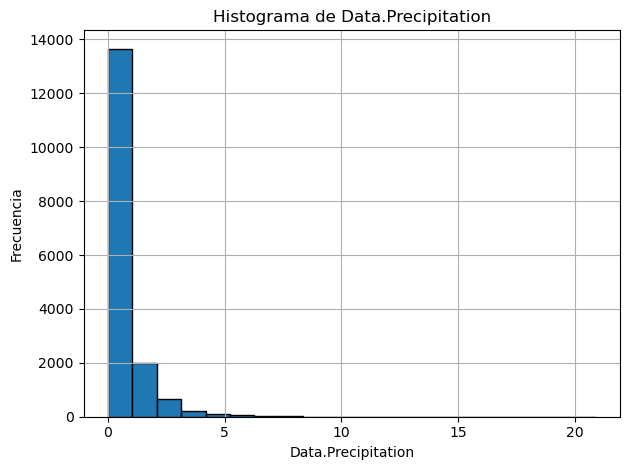

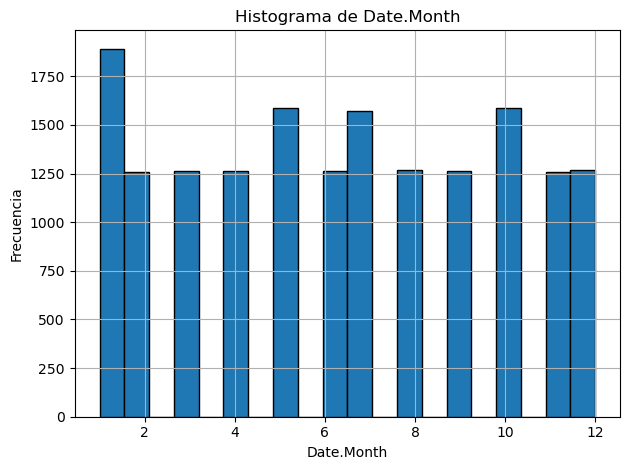

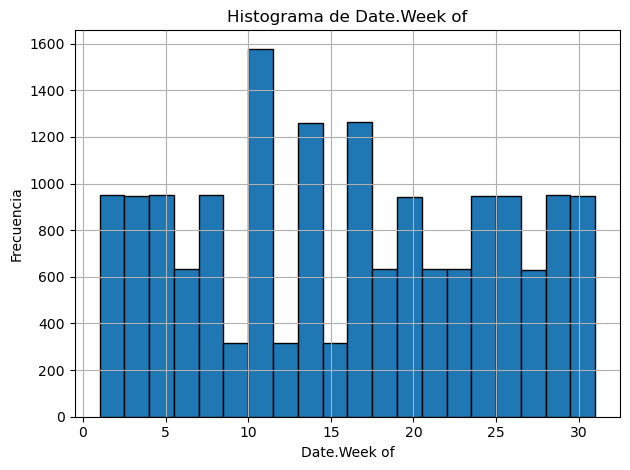

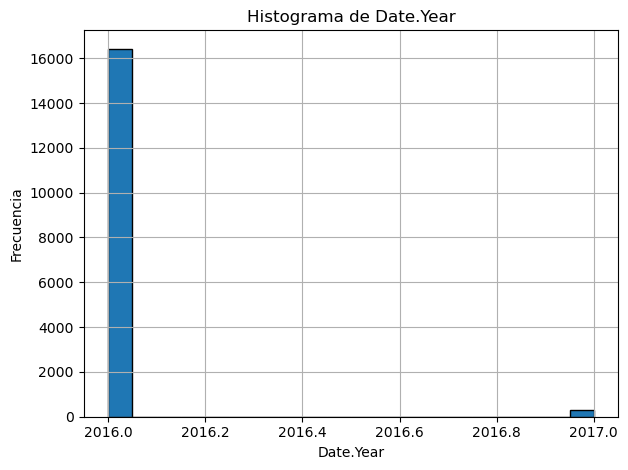

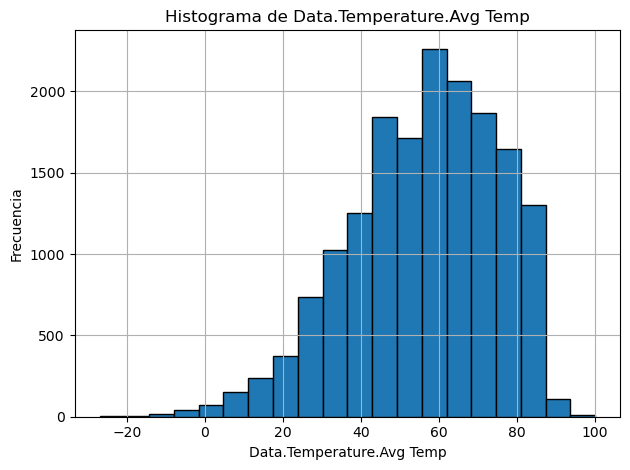

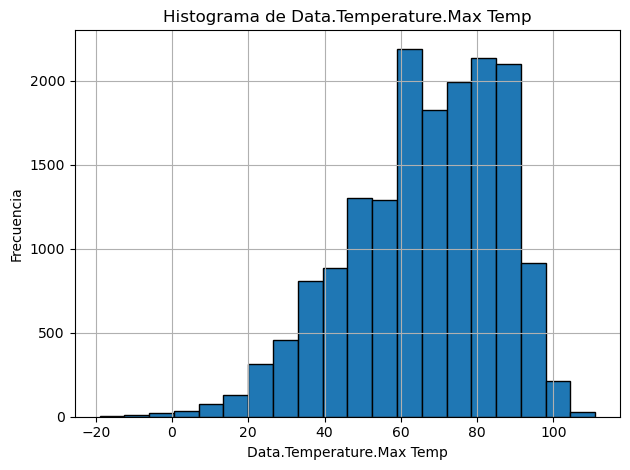

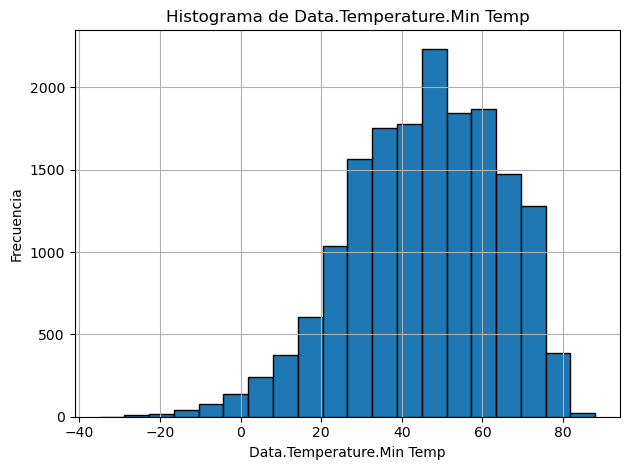

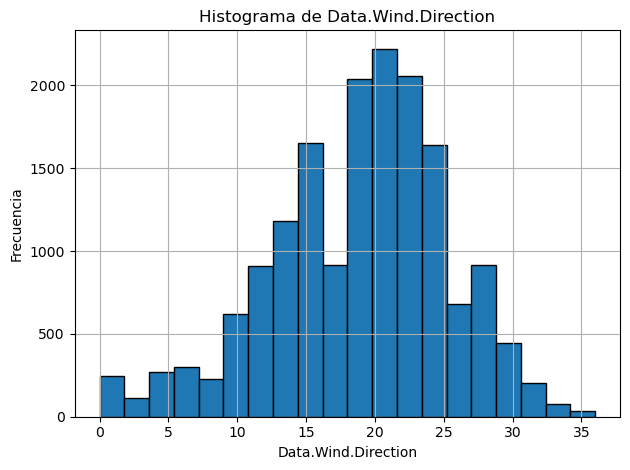

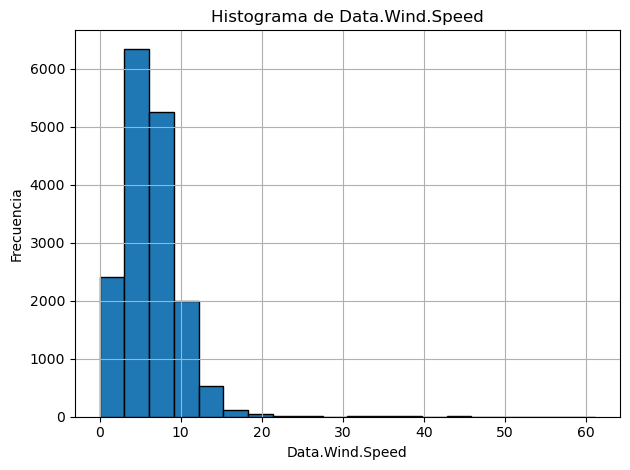

In [19]:
# Generar histogramas para cada columna numérica
numeric_cols = df.select_dtypes(include='number').columns
for col in numeric_cols:
    plt.figure()
    df[col].hist(bins=20, edgecolor='black')
    plt.title(f'Histograma de {col}')
    plt.xlabel(col)
    plt.ylabel('Frecuencia')
    plt.grid(True)
    plt.tight_layout()
    plt.savefig(f"histograma_{col.replace(' ', '_')}.png")
    plt.show()

In [23]:
# Columnas para tablas de frecuencia
columnas_objetivo = ['Data.Precipitation', 'Data.Wind.Speed']
df[columnas_objetivo] = df[columnas_objetivo].apply(pd.to_numeric, errors='coerce')

# Tablas de frecuencia
for col in columnas_objetivo:
    print(f"\\n=== Tabla de frecuencias: {col} ===")
    bins = pd.cut(df[col].dropna(), bins=10)
    frecuencia = bins.value_counts().sort_index()
    frecuencia_acumulada = frecuencia.cumsum()
    frecuencia_relativa = frecuencia / frecuencia.sum()
    frecuencia_relativa_acumulada = frecuencia_relativa.cumsum()

    tabla = pd.DataFrame({
        'Rango': frecuencia.index.astype(str),
        'Frecuencia': frecuencia.values,
        'Frecuencia Acumulada': frecuencia_acumulada.values,
        'Frecuencia Relativa': frecuencia_relativa.values,
        'Frecuencia Relativa Acumulada': frecuencia_relativa_acumulada.values
    })

    print(tabla.to_string(index=False))


\n=== Tabla de frecuencias: Data.Precipitation ===
           Rango  Frecuencia  Frecuencia Acumulada  Frecuencia Relativa  Frecuencia Relativa Acumulada
(-0.0209, 2.089]       15636                 15636             0.934329                       0.934329
  (2.089, 4.178]         888                 16524             0.053062                       0.987392
  (4.178, 6.267]         149                 16673             0.008903                       0.996295
  (6.267, 8.356]          42                 16715             0.002510                       0.998805
 (8.356, 10.445]          11                 16726             0.000657                       0.999462
(10.445, 12.534]           4                 16730             0.000239                       0.999701
(12.534, 14.623]           3                 16733             0.000179                       0.999880
(14.623, 16.712]           1                 16734             0.000060                       0.999940
(16.712, 18.801]      

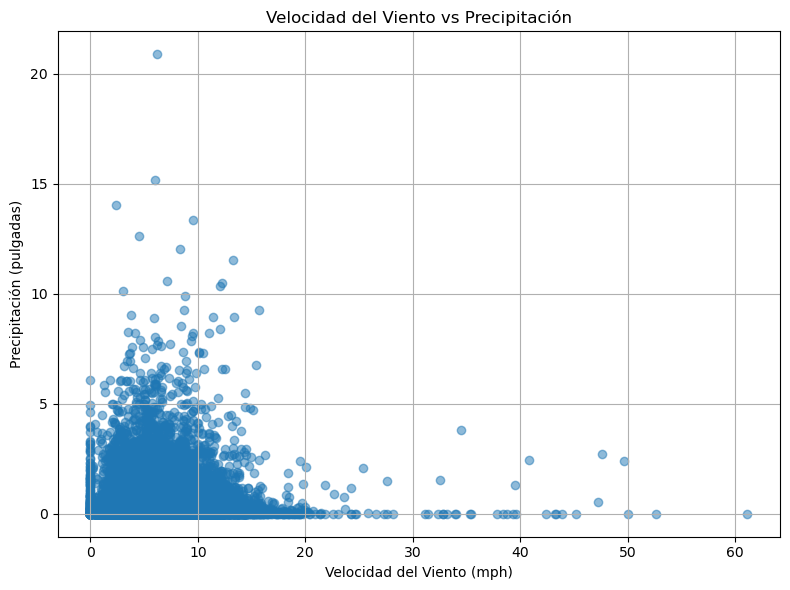

In [25]:
# Asegurarse de que los datos son numéricos y sin nulos para el gráfico
df['Data.Precipitation'] = pd.to_numeric(df['Data.Precipitation'], errors='coerce')
df['Data.Wind.Speed'] = pd.to_numeric(df['Data.Wind.Speed'], errors='coerce')

# Eliminar filas con valores faltantes en las dos columnas
df_limpio = df[['Data.Wind.Speed', 'Data.Precipitation']].dropna()

# Crear el gráfico de dispersión
plt.figure(figsize=(8, 6))
plt.scatter(df_limpio['Data.Wind.Speed'], df_limpio['Data.Precipitation'], alpha=0.5)
plt.title('Velocidad del Viento vs Precipitación')
plt.xlabel('Velocidad del Viento (mph)')
plt.ylabel('Precipitación (pulgadas)')
plt.grid(True)
plt.tight_layout()
plt.show()